In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
def generate_data(num_samples):
    np.random.seed(42)
    X = np.random.rand(num_samples, 1) * 10
    y = 3 * X + 7 + np.random.randn(num_samples, 1)
    return X, y

In [ ]:
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [ ]:
def batch_gradient_descent(X, y, epochs, lr=0.01 ):
    m, n = X.shape
    X = np.c_[np.ones((m, 1)), X]
    theta = np.random.randn(n + 1, 1)
    losses = []

    for epoch in range(epochs):
        predictions = X.dot(theta)
        errors = predictions - y
        gradients = 2 / m * X.T.dot(errors)
        theta -= lr * gradients
        loss = compute_loss(y, predictions)
        losses.append(loss)

    return theta, losses

In [ ]:
def stochastic_gradient_descent(X, y,epochs, lr=0.01 ):
    m, n = X.shape
    X = np.c_[np.ones((m, 1)), X]
    theta = np.random.randn(n + 1, 1)
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        random_index = np.random.randint(m)
        xi = X[random_index:random_index + 1]
        yi = y[random_index:random_index + 1]
        predictions = xi.dot(theta)
        errors = predictions - yi
        gradients = 2 * xi.T.dot(errors)
        theta -= lr * gradients
        epoch_loss += compute_loss(yi, predictions)
        losses.append(epoch_loss)

    return theta, losses


In [ ]:
small_dataset_size = 1000
large_dataset_size = 10000000

X_small, y_small = generate_data(small_dataset_size)
X_large, y_large = generate_data(large_dataset_size)

In [ ]:
#for small dataset
start_time = time.time()
theta_bgd_small, losses_bgd_small = batch_gradient_descent(X_small, y_small, epochs=50)
time_bgd_small = time.time() - start_time

#for large dataset
start_time = time.time()
theta_bgd_large, losses_bgd_large = batch_gradient_descent(X_large, y_large, epochs=50)
time_bgd_large = time.time() - start_time

In [ ]:
#for small dataset
start_time = time.time()
theta_sgd_small, losses_sgd_small = stochastic_gradient_descent(X_small, y_small, epochs=50)
time_sgd_small = time.time() - start_time

#for large dataset
start_time = time.time()
theta_sgd_large, losses_sgd_large = stochastic_gradient_descent(X_large, y_large, epochs=50)
time_sgd_large = time.time() - start_time

Batch Gradient Descent (Small Dataset): Time = 0.0049s, Final Loss = 9.4474
Batch Gradient Descent (Large Dataset): Time = 13.4937s, Final Loss = 7.6046
Stochastic Gradient Descent (Small Dataset): Time = 0.0058s, Final Loss = 4.0660
Stochastic Gradient Descent (Large Dataset): Time = 0.1791s, Final Loss = 28.4700


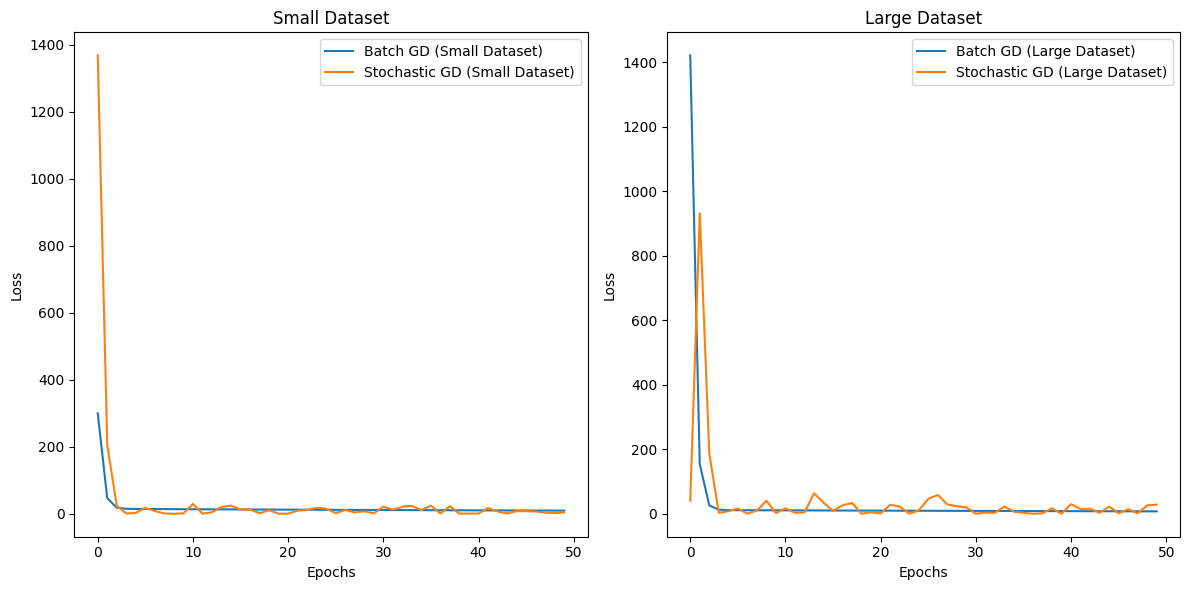

In [ ]:
print("Batch Gradient Descent (Small Dataset): Time = {:.4f}s, Final Loss = {:.4f}".format(time_bgd_small, losses_bgd_small[-1]))
print("Batch Gradient Descent (Large Dataset): Time = {:.4f}s, Final Loss = {:.4f}".format(time_bgd_large, losses_bgd_large[-1]))
print("Stochastic Gradient Descent (Small Dataset): Time = {:.4f}s, Final Loss = {:.4f}".format(time_sgd_small, losses_sgd_small[-1]))
print("Stochastic Gradient Descent (Large Dataset): Time = {:.4f}s, Final Loss = {:.4f}".format(time_sgd_large, losses_sgd_large[-1]))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses_bgd_small, label="Batch GD (Small Dataset)")
plt.plot(losses_sgd_small, label="Stochastic GD (Small Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Small Dataset")

plt.subplot(1, 2, 2)
plt.plot(losses_bgd_large, label="Batch GD (Large Dataset)")
plt.plot(losses_sgd_large, label="Stochastic GD (Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Large Dataset")

plt.tight_layout()
plt.show()